In [2]:
# 05_baseline.ipynb - Baseline моделі (Logistic Regression та Random Forest)
print("BASELINE моделі")

import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.model_selection import cross_val_score
import joblib
import json
from datetime import datetime

from src.config import DATA_DIR, MODELS_DIR, FIGURES_DIR, RANDOM_SEED

%matplotlib inline

# Налаштування
plt.rcParams['figure.figsize'] = (12, 6)
(FIGURES_DIR / 'baseline').mkdir(parents=True, exist_ok=True)
(MODELS_DIR / 'baseline').mkdir(parents=True, exist_ok=True)


BASELINE моделі


In [6]:
print("Завантаження даних...")

# Завантажуємо агреговані ознаки для baseline 
X_train = pd.read_csv(DATA_DIR / 'X_train_features.csv')
X_val = pd.read_csv(DATA_DIR / 'X_val_features.csv')
X_test = pd.read_csv(DATA_DIR / 'X_test_features.csv')

# Завантажуємо мітки (numpy binary files)
y_train = np.load(DATA_DIR / 'y_train.npy')
y_val = np.load(DATA_DIR / 'y_val.npy')
y_test = np.load(DATA_DIR / 'y_test.npy')

print(f"\n Дані завантажено:")
print(f"  Train: {X_train.shape[0]:,} сесій, {X_train.shape[1]} ознак")
print(f"  Val:   {X_val.shape[0]:,} сесій, {X_val.shape[1]} ознак")
print(f"  Test:  {X_test.shape[0]:,} сесій, {X_test.shape[1]} ознак")

print(f"\n Розподіл класів в train:")
print(f"  Якісні (1): {y_train.sum():,} ({y_train.mean()*100:.2f}%)")
print(f"  Неякісні (0): {(len(y_train)-y_train.sum()):,} ({(1-y_train.mean())*100:.2f}%)")

Завантаження даних...

 Дані завантажено:
  Train: 6,474,810 сесій, 7 ознак
  Val:   1,387,459 сесій, 7 ознак
  Test:  1,387,460 сесій, 7 ознак

 Розподіл класів в train:
  Якісні (1): 356,726 (5.51%)
  Неякісні (0): 6,118,084 (94.49%)


Аналіз ознак

Описові статистики ознак:


,length,unique_items,diversity,repeat_ratio,most_common,first_item,last_item
count,6.474810e+06,6.474810e+06,6.474810e+06,6.474810e+06,6.474810e+06,6.474810e+06,6.474810e+06
mean,3.243382e+00,2.658923e+00,8.535265e-01,1.464735e-01,5.755864e-01,3.373697e+04,3.310084e+04
std,2.155977e+00,1.813189e+00,2.178339e-01,2.178339e-01,2.872802e-01,1.630405e+04,1.632696e+04
min,1.000000e+00,1.000000e+00,1.111111e-01,0.000000e+00,1.111111e-01,1.000000e+00,1.000000e+00
25%,2.000000e+00,1.000000e+00,6.666667e-01,0.000000e+00,3.333333e-01,2.072800e+04,2.021800e+04
50%,2.000000e+00,2.000000e+00,1.000000e+00,0.000000e+00,5.000000e-01,4.182200e+04,4.122100e+04
75%,4.000000e+00,3.000000e+00,1.000000e+00,3.333333e-01,1.000000e+00,4.763300e+04,4.749300e+04
max,9.000000e+00,9.000000e+00,1.000000e+00,8.888889e-01,1.000000e+00,5.273900e+04,5.273900e+04



Кореляція ознак з цільовою змінною:
  length: 0.1963
  repeat_ratio: 0.1300
  diversity: -0.1300
  unique_items: 0.1272
  most_common: -0.0494
  first_item: 0.0246
  last_item: 0.0220


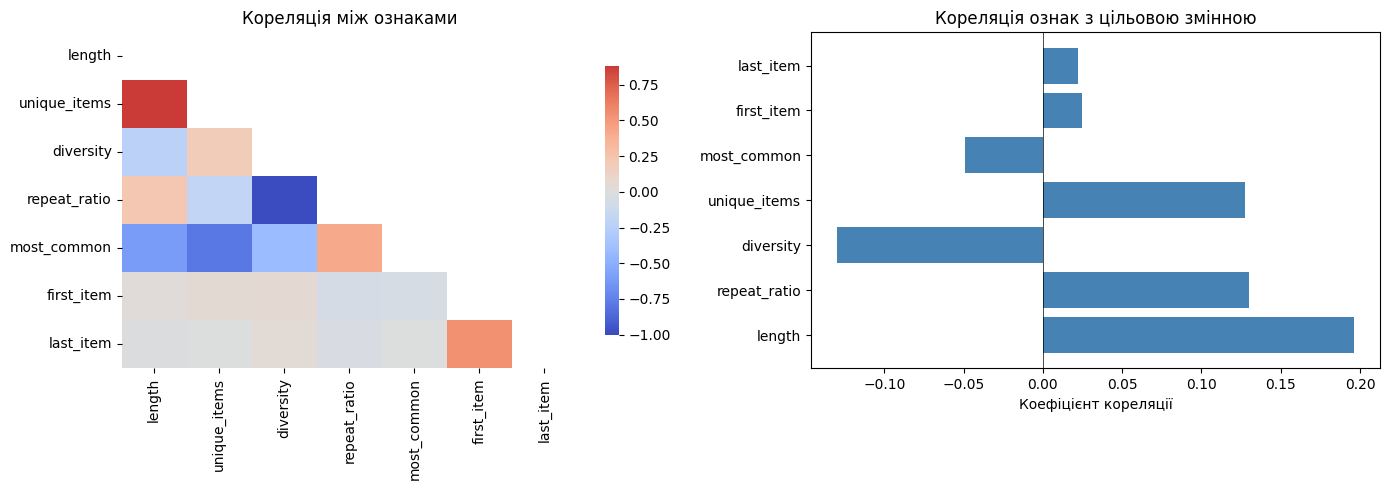

In [7]:
print("Аналіз ознак")

print("\nОписові статистики ознак:")
display(X_train.describe())

# Кореляція з цільовою змінною
print("\nКореляція ознак з цільовою змінною:")
correlations = []
for col in X_train.columns:
    corr = np.corrcoef(X_train[col], y_train)[0, 1]
    correlations.append((col, corr))

correlations.sort(key=lambda x: abs(x[1]), reverse=True)
for col, corr in correlations:
    print(f"  {col}: {corr:.4f}")

# Візуалізація кореляцій
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Теплова карта кореляцій між ознаками
corr_matrix = X_train.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm', center=0, 
            ax=axes[0], cbar_kws={'shrink': 0.8})
axes[0].set_title('Кореляція між ознаками')

# Кореляція з цільовою змінною
corr_with_target = [corr for col, corr in correlations]
axes[1].barh([c[0] for c in correlations], corr_with_target, color='steelblue')
axes[1].axvline(0, color='black', linestyle='-', linewidth=0.5)
axes[1].set_title('Кореляція ознак з цільовою змінною')
axes[1].set_xlabel('Коефіцієнт кореляції')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'baseline/feature_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

In [8]:
print("LOGISTIC REGRESSION")

# Створюємо модель
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_SEED,
    class_weight='balanced',  # враховуємо дисбаланс класів
    C=1.0  # сила регуляризації
)

print("Тренування Logistic Regression...")
lr_model.fit(X_train, y_train)

# Передбачення
y_pred_lr = lr_model.predict(X_val)
y_pred_proba_lr = lr_model.predict_proba(X_val)[:, 1]

# Метрики
metrics_lr = {
    'accuracy': accuracy_score(y_val, y_pred_lr),
    'f1_score': f1_score(y_val, y_pred_lr),
    'roc_auc': roc_auc_score(y_val, y_pred_proba_lr)
}

print(f"\n Метрики на VALIDATION:")
for metric, value in metrics_lr.items():
    print(f"  {metric}: {value:.4f}")

# Classification report
print(f"\nClassification Report:")
print(classification_report(y_val, y_pred_lr, target_names=['Неякісні', 'Якісні']))

# Коєфіцієнти моделі
feature_importance_lr = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': lr_model.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)

print(f"\nНайважливіші ознаки (за коефіцієнтами):")
print(feature_importance_lr.head(10))

LOGISTIC REGRESSION
Тренування Logistic Regression...

 Метрики на VALIDATION:
  accuracy: 0.6817
  f1_score: 0.1882
  roc_auc: 0.7328

Classification Report:
              precision    recall  f1-score   support

    Неякісні       0.97      0.68      0.80   1311018
      Якісні       0.11      0.67      0.19     76441

    accuracy                           0.68   1387459
   macro avg       0.54      0.68      0.50   1387459
weighted avg       0.92      0.68      0.77   1387459


Найважливіші ознаки (за коефіцієнтами):
        feature  coefficient
2     diversity    -1.349198
3  repeat_ratio     0.677423
0        length     0.225418
4   most_common     0.220968
1  unique_items     0.082879
6     last_item     0.000006
5    first_item     0.000004


In [9]:
print("RANDOM FOREST")

# Створюємо модель
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=RANDOM_SEED,
    class_weight='balanced',
    n_jobs=-1  # використовуємо всі ядра
)

print("Тренування Random Forest...")
rf_model.fit(X_train, y_train)

# Передбачення
y_pred_rf = rf_model.predict(X_val)
y_pred_proba_rf = rf_model.predict_proba(X_val)[:, 1]

# Метрики
metrics_rf = {
    'accuracy': accuracy_score(y_val, y_pred_rf),
    'f1_score': f1_score(y_val, y_pred_rf),
    'roc_auc': roc_auc_score(y_val, y_pred_proba_rf)
}

print(f"\n Метрики на VALIDATION:")
for metric, value in metrics_rf.items():
    print(f"  {metric}: {value:.4f}")

# Classification report
print(f"\nClassification Report:")
print(classification_report(y_val, y_pred_rf, target_names=['Неякісні', 'Якісні']))

# Важливість ознак
feature_importance_rf = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\nНайважливіші ознаки (за важливістю):")
print(feature_importance_rf.head(10))

RANDOM FOREST
Тренування Random Forest...

 Метрики на VALIDATION:
  accuracy: 0.6999
  f1_score: 0.2002
  roc_auc: 0.7520

Classification Report:
              precision    recall  f1-score   support

    Неякісні       0.97      0.70      0.82   1311018
      Якісні       0.12      0.68      0.20     76441

    accuracy                           0.70   1387459
   macro avg       0.55      0.69      0.51   1387459
weighted avg       0.93      0.70      0.78   1387459


Найважливіші ознаки (за важливістю):
        feature  importance
0        length    0.241896
3  repeat_ratio    0.232162
2     diversity    0.199015
1  unique_items    0.123992
4   most_common    0.075221
5    first_item    0.063998
6     last_item    0.063716


Порівняння моделей

 Порівняння метрик:


,Model,Accuracy,F1-Score,ROC-AUC
0,Logistic Regression,0.681743,0.188154,0.732799
1,Random Forest,0.699944,0.200232,0.752020


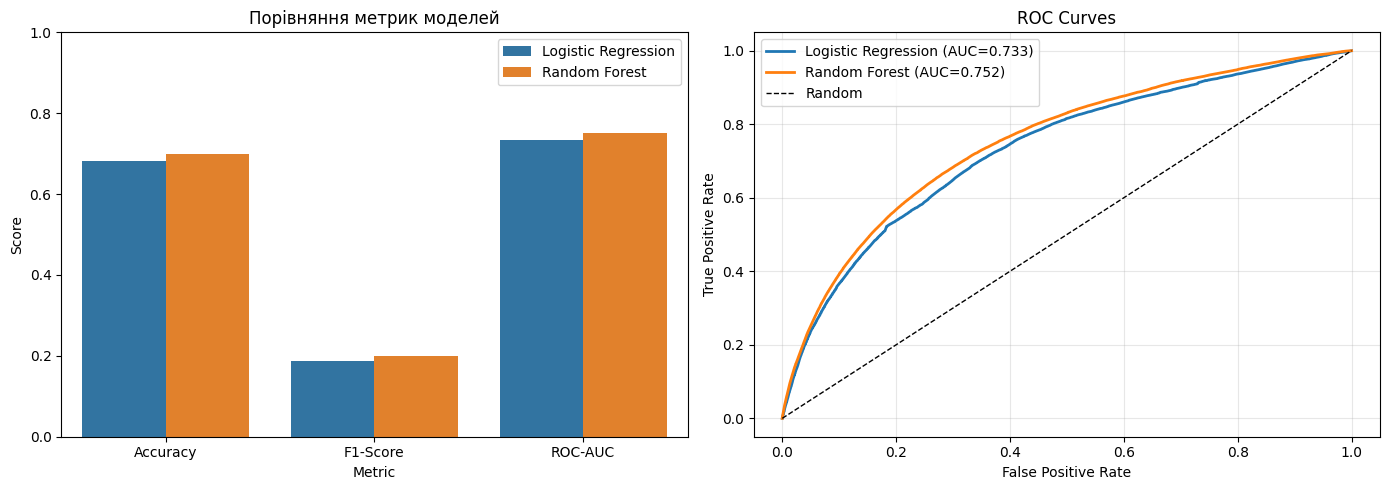

In [10]:
print("Порівняння моделей")

# Збираємо результати
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [metrics_lr['accuracy'], metrics_rf['accuracy']],
    'F1-Score': [metrics_lr['f1_score'], metrics_rf['f1_score']],
    'ROC-AUC': [metrics_lr['roc_auc'], metrics_rf['roc_auc']]
})

print("\n Порівняння метрик:")
display(comparison)

# Візуалізація порівняння
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot метрик
comparison_melted = comparison.melt(id_vars=['Model'], var_name='Metric', value_name='Score')
sns.barplot(data=comparison_melted, x='Metric', y='Score', hue='Model', ax=axes[0])
axes[0].set_title('Порівняння метрик моделей')
axes[0].set_ylim(0, 1)
axes[0].legend()

# ROC Curves
from sklearn.metrics import roc_curve

# LR ROC
fpr_lr, tpr_lr, _ = roc_curve(y_val, y_pred_proba_lr)
axes[1].plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={metrics_lr["roc_auc"]:.3f})', linewidth=2)

# RF ROC
fpr_rf, tpr_rf, _ = roc_curve(y_val, y_pred_proba_rf)
axes[1].plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={metrics_rf["roc_auc"]:.3f})', linewidth=2)

axes[1].plot([0, 1], [0, 1], 'k--', label='Random', linewidth=1)
axes[1].set_title('ROC Curves')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'baseline/model_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

MATRICES помилок


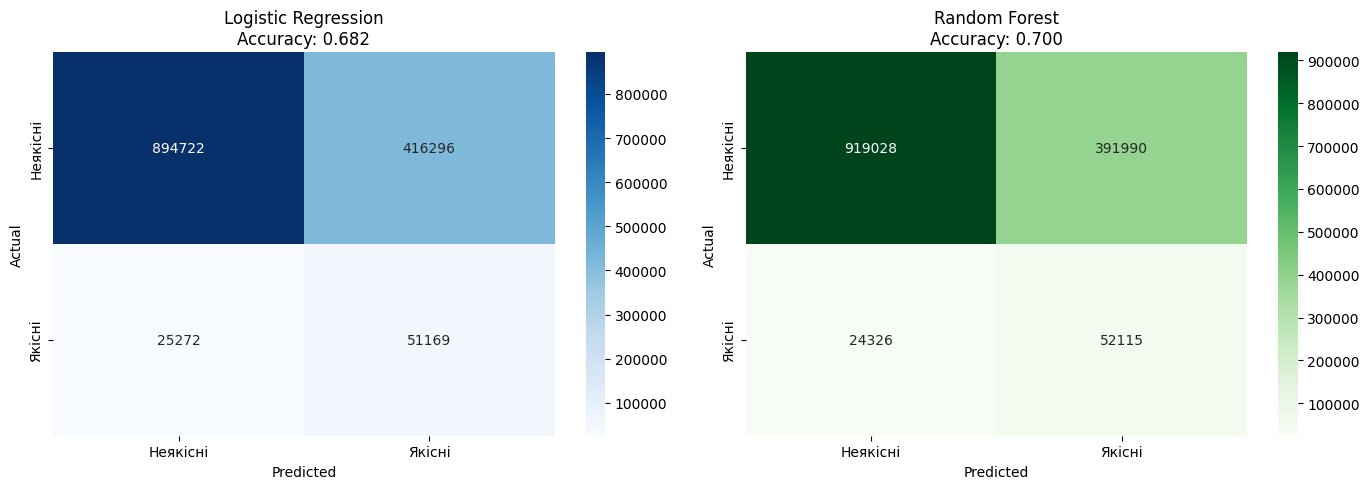


 Детальний аналіз помилок (Random Forest):
  True Negatives (правильно неякісні): 919,028
  False Positives (хибно якісні): 391,990
  False Negatives (хибно неякісні): 24,326
  True Positives (правильно якісні): 52,115

  Precision: 0.1173
  Recall: 0.6818
  F1-Score: 0.2002


In [11]:
print("MATRICES помилок")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Logistic Regression
cm_lr = confusion_matrix(y_val, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Неякісні', 'Якісні'],
            yticklabels=['Неякісні', 'Якісні'])
axes[0].set_title(f'Logistic Regression\nAccuracy: {metrics_lr["accuracy"]:.3f}')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Random Forest
cm_rf = confusion_matrix(y_val, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Неякісні', 'Якісні'],
            yticklabels=['Неякісні', 'Якісні'])
axes[1].set_title(f'Random Forest\nAccuracy: {metrics_rf["accuracy"]:.3f}')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'baseline/confusion_matrices.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n Детальний аналіз помилок (Random Forest):")
tn, fp, fn, tp = cm_rf.ravel()
print(f"  True Negatives (правильно неякісні): {tn:,}")
print(f"  False Positives (хибно якісні): {fp:,}")
print(f"  False Negatives (хибно неякісні): {fn:,}")
print(f"  True Positives (правильно якісні): {tp:,}")

precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
print(f"\n  Precision: {precision:.4f}")
print(f"  Recall: {recall:.4f}")
print(f"  F1-Score: {2 * precision * recall / (precision + recall):.4f}")

CROSS-VALIDATION
Проведення 5-fold cross-validation для Random Forest...

 Cross-validation F1-Scores:
  Fold 1: 0.2007
  Fold 2: 0.2004
  Fold 3: 0.2013
  Fold 4: 0.2001
  Fold 5: 0.2013
  Середнє: 0.2008
  Стандартне відхилення: 0.0005


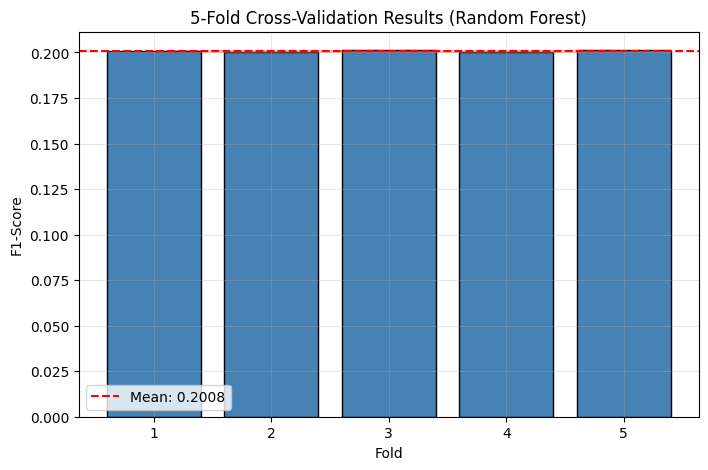

In [12]:
print("CROSS-VALIDATION")

# Cross-validation для Random Forest 
print("Проведення 5-fold cross-validation для Random Forest...")

cv_scores = cross_val_score(
    rf_model, 
    X_train, 
    y_train, 
    cv=5, 
    scoring='f1',
    n_jobs=-1
)

print(f"\n Cross-validation F1-Scores:")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {score:.4f}")
print(f"  Середнє: {cv_scores.mean():.4f}")
print(f"  Стандартне відхилення: {cv_scores.std():.4f}")

# Візуалізація CV результатів
plt.figure(figsize=(8, 5))
plt.bar(range(1, 6), cv_scores, color='steelblue', edgecolor='black')
plt.axhline(cv_scores.mean(), color='red', linestyle='--', label=f'Mean: {cv_scores.mean():.4f}')
plt.fill_between(range(1, 6), cv_scores.mean() - cv_scores.std(), 
                 cv_scores.mean() + cv_scores.std(), alpha=0.2, color='red')
plt.title('5-Fold Cross-Validation Results (Random Forest)')
plt.xlabel('Fold')
plt.ylabel('F1-Score')
plt.xticks(range(1, 6))
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(FIGURES_DIR / 'baseline/cross_validation.png', dpi=100, bbox_inches='tight')
plt.show()

Фінальне тестування на TEST SET
Вибрана модель: Random Forest

 Метрики на TEST SET:
  accuracy: 0.7007
  f1_score: 0.2014
  roc_auc: 0.7535

Classification Report on Test:
              precision    recall  f1-score   support

    Неякісні       0.97      0.70      0.82   1311019
      Якісні       0.12      0.68      0.20     76441

    accuracy                           0.70   1387460
   macro avg       0.55      0.69      0.51   1387460
weighted avg       0.93      0.70      0.78   1387460



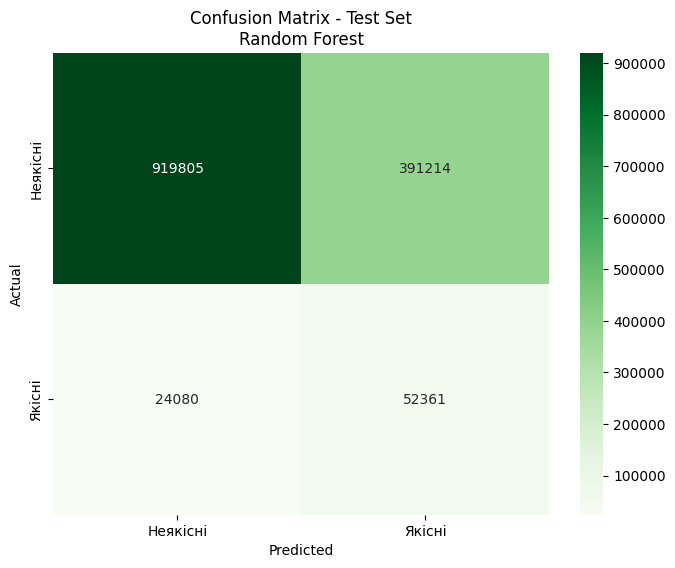

In [13]:
print("Фінальне тестування на TEST SET")

best_model = rf_model
best_model_name = "Random Forest"

print(f"Вибрана модель: {best_model_name}")

# Передбачення на test
y_pred_test = best_model.predict(X_test)
y_pred_proba_test = best_model.predict_proba(X_test)[:, 1]

# Метрики на test
test_metrics = {
    'accuracy': accuracy_score(y_test, y_pred_test),
    'f1_score': f1_score(y_test, y_pred_test),
    'roc_auc': roc_auc_score(y_test, y_pred_proba_test)
}

print(f"\n Метрики на TEST SET:")
for metric, value in test_metrics.items():
    print(f"  {metric}: {value:.4f}")

# Classification report
print(f"\nClassification Report on Test:")
print(classification_report(y_test, y_pred_test, target_names=['Неякісні', 'Якісні']))

# Confusion matrix on test
cm_test = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Неякісні', 'Якісні'],
            yticklabels=['Неякісні', 'Якісні'])
plt.title(f'Confusion Matrix - Test Set\n{best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig(FIGURES_DIR / 'baseline/test_confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

In [14]:
print("Збереження моделей")

# Зберігаємо обидві моделі
joblib.dump(lr_model, MODELS_DIR / 'baseline' / 'logistic_regression.pkl')
joblib.dump(rf_model, MODELS_DIR / 'baseline' / 'random_forest.pkl')

print(f" Моделі збережено:")
print(f"  {MODELS_DIR / 'baseline' / 'logistic_regression.pkl'}")
print(f"  {MODELS_DIR / 'baseline' / 'random_forest.pkl'}")

# Зберігаємо результати
baseline_results = {
    'model_name': best_model_name,
    'train_time': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'random_seed': RANDOM_SEED,
    'validation_metrics': {
        'logistic_regression': metrics_lr,
        'random_forest': metrics_rf
    },
    'test_metrics': test_metrics,
    'cv_scores': {
        'mean': float(cv_scores.mean()),
        'std': float(cv_scores.std()),
        'folds': cv_scores.tolist()
    },
    'feature_importance': feature_importance_rf.to_dict('records')[:10],
    'best_model_params': best_model.get_params()
}

with open(MODELS_DIR / 'baseline' / 'baseline_results.json', 'w', encoding='utf-8') as f:
    json.dump(baseline_results, f, indent=4, default=str)

print(f"\n Результати збережено: {MODELS_DIR / 'baseline' / 'baseline_results.json'}")

Збереження моделей
 Моделі збережено:
  d:\University\kursova\kursova\notebooks\..\models\baseline\logistic_regression.pkl
  d:\University\kursova\kursova\notebooks\..\models\baseline\random_forest.pkl

 Результати збережено: d:\University\kursova\kursova\notebooks\..\models\baseline\baseline_results.json


In [17]:
print("Підсумковий звіт BASELINE")

print(f"""
                    BASELINE РЕЗУЛЬТАТИ                       

  КРАЩА МОДЕЛЬ: {best_model_name:<35} 

  VALIDATION МЕТРИКИ:                                         
    Accuracy:  {test_metrics['accuracy']:.4f} ({test_metrics['accuracy']*100:.2f}%)                    
    F1-Score:  {test_metrics['f1_score']:.4f} ({test_metrics['f1_score']*100:.2f}%)                    
    ROC-AUC:   {test_metrics['roc_auc']:.4f} ({test_metrics['roc_auc']*100:.2f}%)                    
  TEST МЕТРИКИ:                                               
    Accuracy:  {test_metrics['accuracy']:.4f} ({test_metrics['accuracy']*100:.2f}%)                    
    F1-Score:  {test_metrics['f1_score']:.4f} ({test_metrics['f1_score']*100:.2f}%)                    
    ROC-AUC:   {test_metrics['roc_auc']:.4f} ({test_metrics['roc_auc']*100:.2f}%)                    
  CROSS-VALIDATION (5-fold):                                  
    Середній F1: {cv_scores.mean():.4f} (±{cv_scores.std():.4f})                            

  НАЙВАЖЛИВІШІ ОЗНАКИ:                                        """)

for i, row in feature_importance_rf.head(5).iterrows():
    print(f"    {i+1}. {row['feature']:<20} {row['importance']:.4f}                     ")

print("""
  ПОРІВНЯННЯ З LSTM (очікуване):                               
    LSTM повинна показати кращі результати завдяки:            
    - Врахуванню послідовності дій                             
    - Здатності виявляти довгострокові залежності              
    - Кращій роботі з часовими патернами                       
""")


Підсумковий звіт BASELINE

                    BASELINE РЕЗУЛЬТАТИ                       

  КРАЩА МОДЕЛЬ: Random Forest                       

  VALIDATION МЕТРИКИ:                                         
    Accuracy:  0.7007 (70.07%)                    
    F1-Score:  0.2014 (20.14%)                    
    ROC-AUC:   0.7535 (75.35%)                    
  TEST МЕТРИКИ:                                               
    Accuracy:  0.7007 (70.07%)                    
    F1-Score:  0.2014 (20.14%)                    
    ROC-AUC:   0.7535 (75.35%)                    
  CROSS-VALIDATION (5-fold):                                  
    Середній F1: 0.2008 (±0.0005)                            

  НАЙВАЖЛИВІШІ ОЗНАКИ:                                        
    1. length               0.2419                     
    4. repeat_ratio         0.2322                     
    3. diversity            0.1990                     
    2. unique_items         0.1240                     
    5. mos